
Accuracy Results



,Model,Train Accuracy,Test Accuracy
0,LogReg (raw),0.865714,0.876667
1,LogReg + Poly(d=3),0.954286,0.963333
2,Shallow MLP (1x2),0.862857,0.876667
3,Deep MLP (4-4-2),0.971429,0.970000


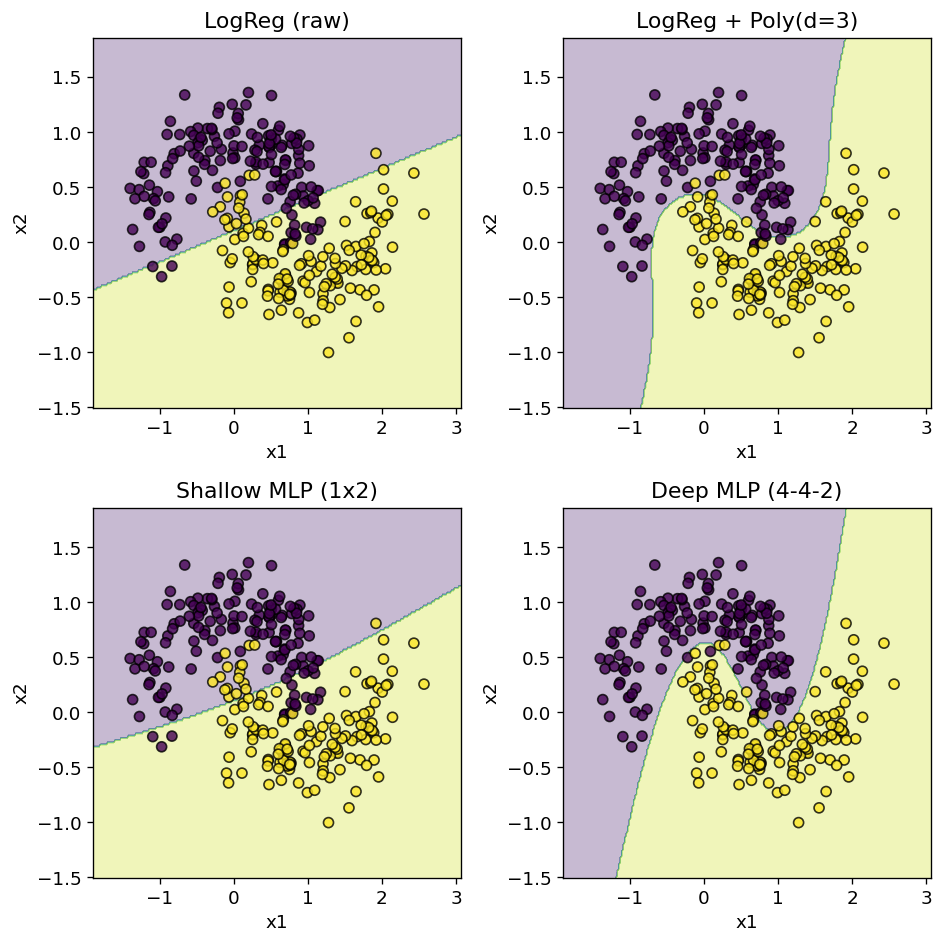

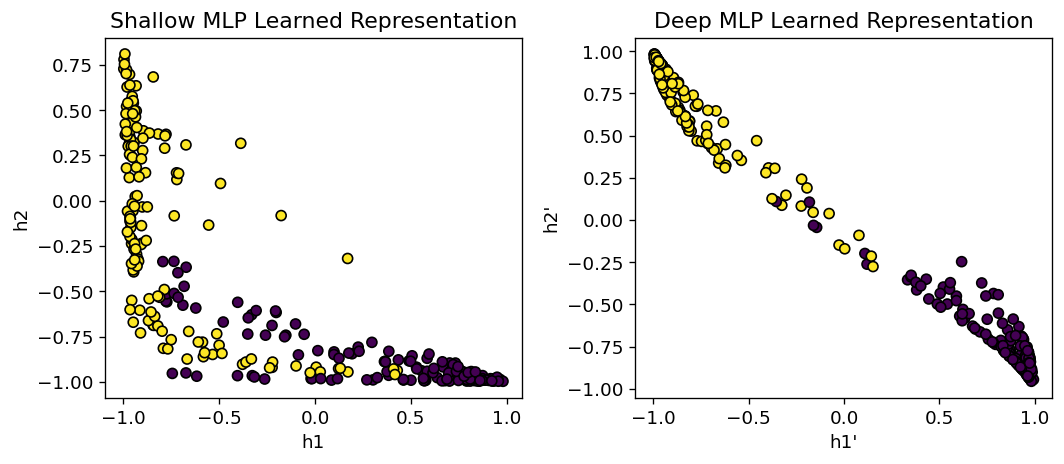

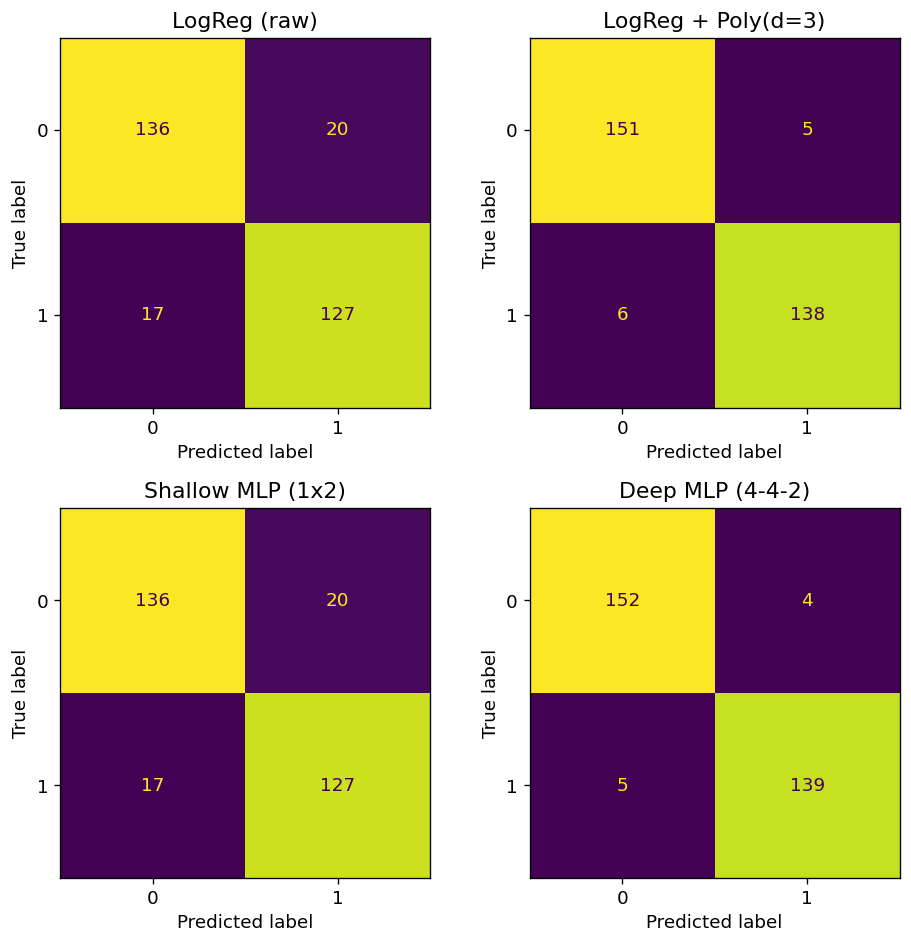

In [1]:
# ================================================================
# Representation Learning vs Feature Engineering
# Single-cell, fully reproducible experiment
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------
# Global settings
# ---------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# ---------------------------
# 1. Dataset
# ---------------------------
X, y = make_moons(n_samples=1000, noise=0.2, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

# ---------------------------
# 2. Decision boundary helper
# ---------------------------
def plot_decision_boundary(model, X, y, ax, title, h=0.02):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

# ---------------------------
# 3. Feature Engineering Models
# ---------------------------
logreg_raw = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=RANDOM_STATE))
])

poly_degree = 3
logreg_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# ---------------------------
# 4. Representation Learning Models
# ---------------------------
shallow_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(2,),
        activation="tanh",
        max_iter=600,
        random_state=RANDOM_STATE
    ))
])

deep_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(4, 4, 2),
        activation="tanh",
        max_iter=900,
        random_state=RANDOM_STATE
    ))
])

models = {
    "LogReg (raw)": logreg_raw,
    f"LogReg + Poly(d={poly_degree})": logreg_poly,
    "Shallow MLP (1x2)": shallow_mlp,
    "Deep MLP (4-4-2)": deep_mlp
}

# ---------------------------
# 5. Train + Evaluate
# ---------------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results.append([name, train_acc, test_acc])

results_df = pd.DataFrame(
    results, columns=["Model", "Train Accuracy", "Test Accuracy"]
)

print("\nAccuracy Results\n")
display(results_df)

# ---------------------------
# 6. Decision Boundaries
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, (name, model) in zip(axes.ravel(), models.items()):
    plot_decision_boundary(model, X_test, y_test, ax, name)

plt.tight_layout()
plt.show()

# ---------------------------
# 7. Extract Learned Representations
# ---------------------------
def get_last_hidden_representation(pipeline, X):
    scaler = pipeline.named_steps["scaler"]
    clf = pipeline.named_steps["clf"]
    X_scaled = scaler.transform(X)
    activations = X_scaled.T
    for i in range(len(clf.hidden_layer_sizes)):
        W = clf.coefs_[i]
        b = clf.intercepts_[i]
        activations = np.tanh(W.T @ activations + b.reshape(-1, 1))
    return activations.T

H_shallow = get_last_hidden_representation(shallow_mlp, X_test)
H_deep = get_last_hidden_representation(deep_mlp, X_test)

# ---------------------------
# 8. Representation Visualization
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].scatter(H_shallow[:, 0], H_shallow[:, 1], c=y_test, edgecolor="k")
axes[0].set_title("Shallow MLP Learned Representation")
axes[0].set_xlabel("h1")
axes[0].set_ylabel("h2")

axes[1].scatter(H_deep[:, 0], H_deep[:, 1], c=y_test, edgecolor="k")
axes[1].set_title("Deep MLP Learned Representation")
axes[1].set_xlabel("h1'")
axes[1].set_ylabel("h2'")

plt.tight_layout()
plt.show()

# ---------------------------
# 9. Confusion Matrices
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, (name, model) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()
